In [41]:
import yfinance as yf
import pandas as pd
from scipy import stats

# USD/IDR ticker on Yahoo Finance is "IDR=X"
usd_idr = yf.Ticker("IDR=X")

# Fetch historical data for the last 5 years
usd_hist = usd_idr.history(period="5y")

# Check timezone before conversion
print("Timezone before conversion:", usd_hist.index.tz)
# Convert timezone to Jakarta (WIB / UTC+7)
usd_hist.index = usd_hist.index.tz_convert('Asia/Jakarta')

# Check timezone after conversion
print("Timezone after conversion:", usd_hist.index.tz)

# Display last 5 rows
print(usd_hist.tail())

Timezone before conversion: Europe/London
Timezone after conversion: Asia/Jakarta
                                   Open          High           Low  \
Date                                                                  
2026-04-08 06:00:00+07:00  17027.400391  17041.000000  16930.000000   
2026-04-09 06:00:00+07:00  17005.500000  17098.300781  16966.900391   
2026-04-10 06:00:00+07:00  17059.000000  17116.000000  17030.800781   
2026-04-13 06:00:00+07:00  17083.000000  17181.699219  17083.000000   
2026-04-14 06:00:00+07:00  17117.000000  17130.000000  17117.000000   

                                  Close  Volume  Dividends  Stock Splits  
Date                                                                      
2026-04-08 06:00:00+07:00  17027.400391       0        0.0           0.0  
2026-04-09 06:00:00+07:00  17005.500000       0        0.0           0.0  
2026-04-10 06:00:00+07:00  17059.000000       0        0.0           0.0  
2026-04-13 06:00:00+07:00  17083.000000      

In [42]:
# Resample to monthly, taking the last closing price of each month
usd_monthly = usd_hist['Close'].resample('M').last()

# Calculate month-over-month percentage change
usd_returns = usd_monthly.pct_change() * 100

# Drop the first row which contains NaN
usd_returns = usd_returns.dropna()

# Display the results
print(usd_returns.head(100))

Date
2021-05-31 00:00:00+07:00   -1.119831
2021-06-30 00:00:00+07:00    2.459025
2021-07-31 00:00:00+07:00   -1.224270
2021-08-31 00:00:00+07:00   -0.608997
2021-09-30 00:00:00+07:00    0.160145
2021-10-31 00:00:00+07:00   -1.084463
2021-11-30 00:00:00+07:00    1.040129
2021-12-31 00:00:00+07:00   -0.638518
2022-01-31 00:00:00+07:00    0.674820
2022-02-28 00:00:00+07:00   -0.329584
2022-03-31 00:00:00+07:00   -0.046743
2022-04-30 00:00:00+07:00    1.217938
2022-05-31 00:00:00+07:00    0.251003
2022-06-30 00:00:00+07:00    2.329002
2022-07-31 00:00:00+07:00   -0.187540
2022-08-31 00:00:00+07:00    0.006064
2022-09-30 00:00:00+07:00    2.189900
2022-10-31 00:00:00+07:00    2.464547
2022-11-30 00:00:00+07:00    1.140250
2022-12-31 00:00:00+07:00   -0.677201
2023-01-31 00:00:00+07:00   -4.001280
2023-02-28 00:00:00+07:00    1.427142
2023-03-31 00:00:00+07:00   -1.242685
2023-04-30 00:00:00+07:00   -2.237017
2023-05-31 00:00:00+07:00    2.008989
2023-06-30 00:00:00+07:00    0.567461
2023-07

/tmp/ipykernel_15520/1340123493.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  usd_monthly = usd_hist['Close'].resample('M').last()


In [43]:
def calculate_usd_beta(ticker_symbol):
    """
    Calculate USD beta for a given stock.
    USD beta measures how sensitive the stock is to USD/IDR movements.
    """
    try:
        # Fetch stock data
        stock = yf.Ticker(ticker_symbol)
        stock_hist = stock.history(period="5y")

        if len(stock_hist) == 0:
            return None

        # Clean index
        stock_hist.index = pd.to_datetime(stock_hist.index)

        # Resample to monthly
        stock_monthly = stock_hist['Close'].resample('ME').last()
        stock_returns = stock_monthly.pct_change() * 100
        stock_returns = stock_returns.dropna()

        # Merge with USD returns
        df = pd.DataFrame({
            'usd_return': usd_returns,
            'stock_return': stock_returns
        })
        df = df.dropna()

        if len(df) < 12:
            return None

        # Calculate correlation and regression
        correlation = df['usd_return'].corr(df['stock_return'])
        slope, _, r_value, p_value, _ = stats.linregress(
            df['usd_return'],
            df['stock_return']
        )

        return {
            'ticker': ticker_symbol.replace('.JK', ''),
            'usd_beta': round(slope, 3),
            'correlation': round(correlation, 3),
            'p_value': round(p_value, 4),
            'r_squared': round(r_value ** 2, 3),
            'significant': p_value < 0.05
        }

    except Exception as e:
        print(f"Error for {ticker_symbol}: {e}")
        return None

In [44]:
# Test on BBCA
bbca_result = calculate_usd_beta("BBCA.JK")
if bbca_result:
    print("=== BBCA ===")
    for key, value in bbca_result.items():
        print(f"{key}: {value}")

# Test on ADRO
adro_result = calculate_usd_beta("ADRO.JK")
if adro_result:
    print("\n=== ADRO ===")
    for key, value in adro_result.items():
        print(f"{key}: {value}")

=== BBCA ===
ticker: BBCA
usd_beta: -0.79
correlation: -0.276
p_value: 0.0331
r_squared: 0.076
significant: True

=== ADRO ===
ticker: ADRO
usd_beta: -1.262
correlation: -0.181
p_value: 0.1653
r_squared: 0.033
significant: False


In [45]:
# Complete LQ45 tickers list (add .JK for Yahoo Finance)
lq45_tickers = [
    "ADRO.JK", "AKRA.JK", "AMRT.JK", "ANTM.JK", "ARTO.JK", "ASII.JK",
    "BBCA.JK", "BBRI.JK", "BBTN.JK", "BBNI.JK", "BDMN.JK", "BMRI.JK",
    "BRIS.JK", "BRPT.JK", "BTPS.JK", "BYAN.JK", "CPIN.JK", "ERAA.JK",
    "EXCL.JK", "GGRM.JK", "GOTO.JK", "HRUM.JK", "ICBP.JK", "INCO.JK",
    "INDF.JK", "INDY.JK", "INKP.JK", "INTP.JK", "ITMG.JK", "JPFA.JK",
    "JSMR.JK", "KLBF.JK", "MDKA.JK", "MEDC.JK", "MIKA.JK", "PGAS.JK",
    "PTBA.JK", "PTPP.JK", "SMGR.JK", "SMRA.JK", "TBIG.JK", "TINS.JK",
    "TKIM.JK", "TLKM.JK", "UNVR.JK"
]

# Calculate USD beta for all LQ45 stocks
results = []

for ticker in lq45_tickers:
    print(f"Processing {ticker}...")
    result = calculate_usd_beta(ticker)
    if result:
        results.append(result)

# Convert to DataFrame for easy viewing
df_results = pd.DataFrame(results)

print(f"Successfully calculated USD Beta for {len(df_results)} out of 45 stocks")

Processing ADRO.JK...
Processing AKRA.JK...
Processing AMRT.JK...
Processing ANTM.JK...
Processing ARTO.JK...
Processing ASII.JK...
Processing BBCA.JK...
Processing BBRI.JK...
Processing BBTN.JK...
Processing BBNI.JK...
Processing BDMN.JK...
Processing BMRI.JK...
Processing BRIS.JK...
Processing BRPT.JK...
Processing BTPS.JK...
Processing BYAN.JK...
Processing CPIN.JK...
Processing ERAA.JK...
Processing EXCL.JK...
Processing GGRM.JK...
Processing GOTO.JK...
Processing HRUM.JK...
Processing ICBP.JK...
Processing INCO.JK...
Processing INDF.JK...
Processing INDY.JK...
Processing INKP.JK...
Processing INTP.JK...
Processing ITMG.JK...
Processing JPFA.JK...
Processing JSMR.JK...
Processing KLBF.JK...
Processing MDKA.JK...
Processing MEDC.JK...
Processing MIKA.JK...
Processing PGAS.JK...
Processing PTBA.JK...
Processing PTPP.JK...
Processing SMGR.JK...
Processing SMRA.JK...
Processing TBIG.JK...
Processing TINS.JK...
Processing TKIM.JK...
Processing TLKM.JK...
Processing UNVR.JK...
Successful

In [46]:
# Sort by USD Beta (highest first - most benefit from weak rupiah)
df_sorted = df_results.sort_values('usd_beta', ascending=False)

print("Top 10 stocks (most benefit from weak rupiah)")
print(df_sorted[['ticker', 'usd_beta']].head(10).to_string(index=False))

print("\nBottom 10 stocks (most hurt by weak rupiah)")
print(df_sorted[['ticker', 'usd_beta']].tail(10).to_string(index=False))

# Filter only statistically significant results
significant_stocks = df_results[df_results['significant'] == True]
print(f"\nStatistically significant results (p-value < 0.05)")
print(f"Found {len(significant_stocks)} stocks with significant USD sensitivity")
print(significant_stocks[['ticker', 'usd_beta']].to_string(index=False))

Top 10 stocks (most benefit from weak rupiah)
ticker  usd_beta
  CPIN     0.794
  JPFA     0.597
  PGAS     0.593
  EXCL     0.415
  MIKA     0.065
  ICBP     0.047
  INDY    -0.017
  AMRT    -0.052
  INDF    -0.089
  AKRA    -0.257

Bottom 10 stocks (most hurt by weak rupiah)
ticker  usd_beta
  BBNI    -1.620
  BBRI    -1.675
  BBTN    -1.734
  GOTO    -1.743
  HRUM    -1.925
  PTPP    -2.168
  ANTM    -2.350
  INCO    -2.531
  MDKA    -2.793
  ARTO    -3.474

Statistically significant results (p-value < 0.05)
Found 14 stocks with significant USD sensitivity
ticker  usd_beta
  ANTM    -2.350
  ARTO    -3.474
  ASII    -1.086
  BBCA    -0.790
  BBRI    -1.675
  BBTN    -1.734
  BBNI    -1.620
  BMRI    -1.114
  INCO    -2.531
  KLBF    -1.016
  MDKA    -2.793
  PTPP    -2.168
  SMRA    -1.527
  TLKM    -1.421


In [47]:
print(f"Total data points: {len(usd_returns)} months")
print(f"Total stocks: {len(df_results)}")

Total data points: 60 months
Total stocks: 45


### 1. Given current USD/IDR at 17,137, which LQ45 stocks are most sensitive to rupiah weakness?



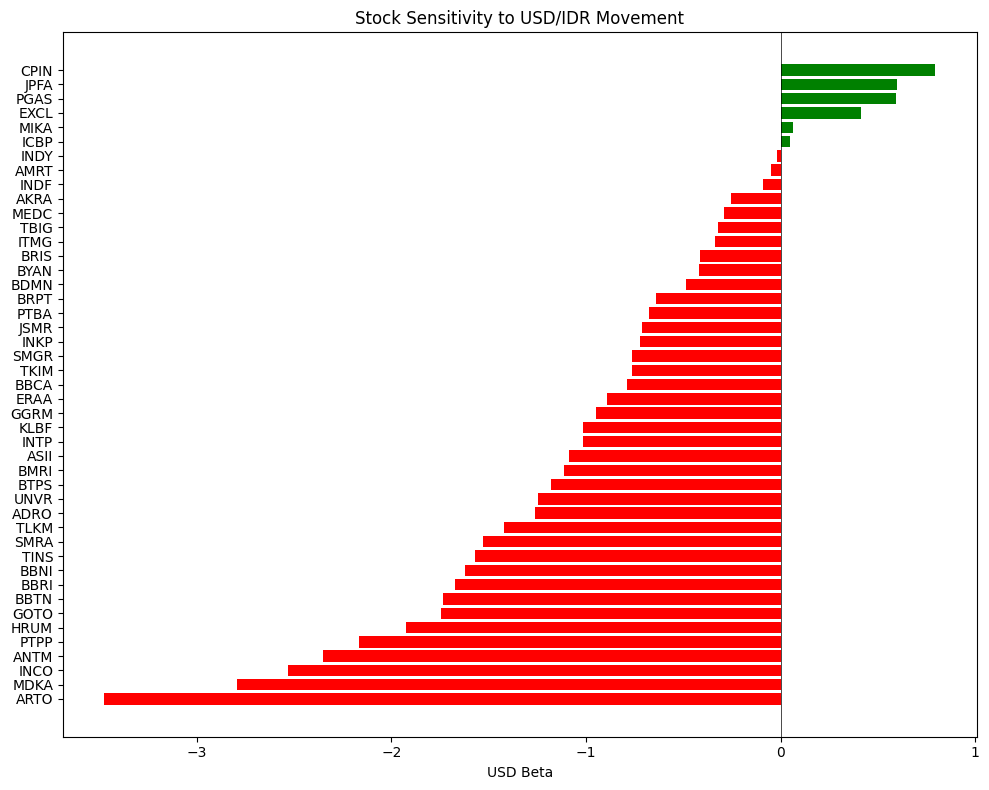

In [48]:
import matplotlib.pyplot as plt

# Plot USD Beta
usd_beta_plot = df_results.set_index('ticker')['usd_beta'].sort_values()

plt.figure(figsize=(10, 8))
colors = ['red' if x < 0 else 'green' for x in usd_beta_plot.values]
plt.barh(usd_beta_plot.index, usd_beta_plot.values, color=colors)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.xlabel('USD Beta')
plt.title('Stock Sensitivity to USD/IDR Movement')
plt.tight_layout()
plt.show()

In [49]:
# Tabel lengkap USD Beta
print("Complete USD Beta for all LQ45 stocks:")
print(df_results[['ticker', 'usd_beta']].sort_values('usd_beta', ascending=False).to_string(index=False))

Complete USD Beta for all LQ45 stocks:
ticker  usd_beta
  CPIN     0.794
  JPFA     0.597
  PGAS     0.593
  EXCL     0.415
  MIKA     0.065
  ICBP     0.047
  INDY    -0.017
  AMRT    -0.052
  INDF    -0.089
  AKRA    -0.257
  MEDC    -0.289
  TBIG    -0.324
  ITMG    -0.337
  BRIS    -0.416
  BYAN    -0.417
  BDMN    -0.487
  BRPT    -0.643
  PTBA    -0.678
  JSMR    -0.710
  INKP    -0.723
  TKIM    -0.764
  SMGR    -0.764
  BBCA    -0.790
  ERAA    -0.893
  GGRM    -0.950
  INTP    -1.016
  KLBF    -1.016
  ASII    -1.086
  BMRI    -1.114
  BTPS    -1.182
  UNVR    -1.246
  ADRO    -1.262
  TLKM    -1.421
  SMRA    -1.527
  TINS    -1.571
  BBNI    -1.620
  BBRI    -1.675
  BBTN    -1.734
  GOTO    -1.743
  HRUM    -1.925
  PTPP    -2.168
  ANTM    -2.350
  INCO    -2.531
  MDKA    -2.793
  ARTO    -3.474


So, using the current currency exchange USD/IDR, we can see that some stocks have more impact than others because they have higher sensitivity. Using USD beta as the parameter, we know that with the nominal currency hitting an all-time high at Rp 17.137 per USD, ARTO, MDKA, and INCO experience significant downside pressure because their USD beta is highly negative at -3.472, -2.797, and -2.534 respectively. This means that for every 1% strengthening in USD/IDR (rupiah weakening), these stocks drop by approximately 2.5% to 3.5%.

Rather than CPIN, JPFA, and PGAS, which have strong positive USD beta at 0.795, 0.697, and 0.594 respectively. This means they benefit meaningfully from a weak rupiah — for every 1% rupiah weakening, these stocks tend to rise by 0.6% to 0.8%.

The USD beta below zero indicates that the stock moves in the opposite direction of USD/IDR. When the rupiah weakens (USD/IDR goes up), stocks with negative USD beta tend to go down. This is typical for companies with foreign currency debt, import-dependent supply chains, or significant foreign investor exposure. Conversely, when the rupiah strengthens, these same stocks would benefit the most.

###2. If the rupiah weakens another 5%, which stocks have the highest earnings sensitivity?

In [50]:
# If rupiah weakens another 5%, calculate expected return
rupiah_weakening = 5  # 5%

df_results['expected_return'] = df_results['usd_beta'] * rupiah_weakening

# Top 10 most positive impact (benefit the most)
positive_impact = df_results.sort_values('expected_return', ascending=False)

# Bottom 10 most negative impact (hurt the most)
negative_impact = df_results.sort_values('expected_return', ascending=True)

print(f"If rupiah weakens another {rupiah_weakening}%:")
print("\nStocks with highest positive expected return:")
print(positive_impact[['ticker', 'usd_beta', 'expected_return']].head(5).to_string(index=False))

print("\nStocks with highest negative expected return:")
print(negative_impact[['ticker', 'usd_beta', 'expected_return']].head(5).to_string(index=False))

print("\n Interpretation:")
print(f"- CPIN, JPFA, PGAS are expected to gain {positive_impact.iloc[0]['expected_return']:.1f}% to {positive_impact.iloc[2]['expected_return']:.1f}%")
print(f"- ARTO, MDKA, INCO are expected to drop {abs(negative_impact.iloc[0]['expected_return']):.1f}% to {abs(negative_impact.iloc[2]['expected_return']):.1f}%")

If rupiah weakens another 5%:

Stocks with highest positive expected return:
ticker  usd_beta  expected_return
  CPIN     0.794            3.970
  JPFA     0.597            2.985
  PGAS     0.593            2.965
  EXCL     0.415            2.075
  MIKA     0.065            0.325

Stocks with highest negative expected return:
ticker  usd_beta  expected_return
  ARTO    -3.474          -17.370
  MDKA    -2.793          -13.965
  INCO    -2.531          -12.655
  ANTM    -2.350          -11.750
  PTPP    -2.168          -10.840

 Interpretation:
- CPIN, JPFA, PGAS are expected to gain 4.0% to 3.0%
- ARTO, MDKA, INCO are expected to drop 17.4% to 12.7%


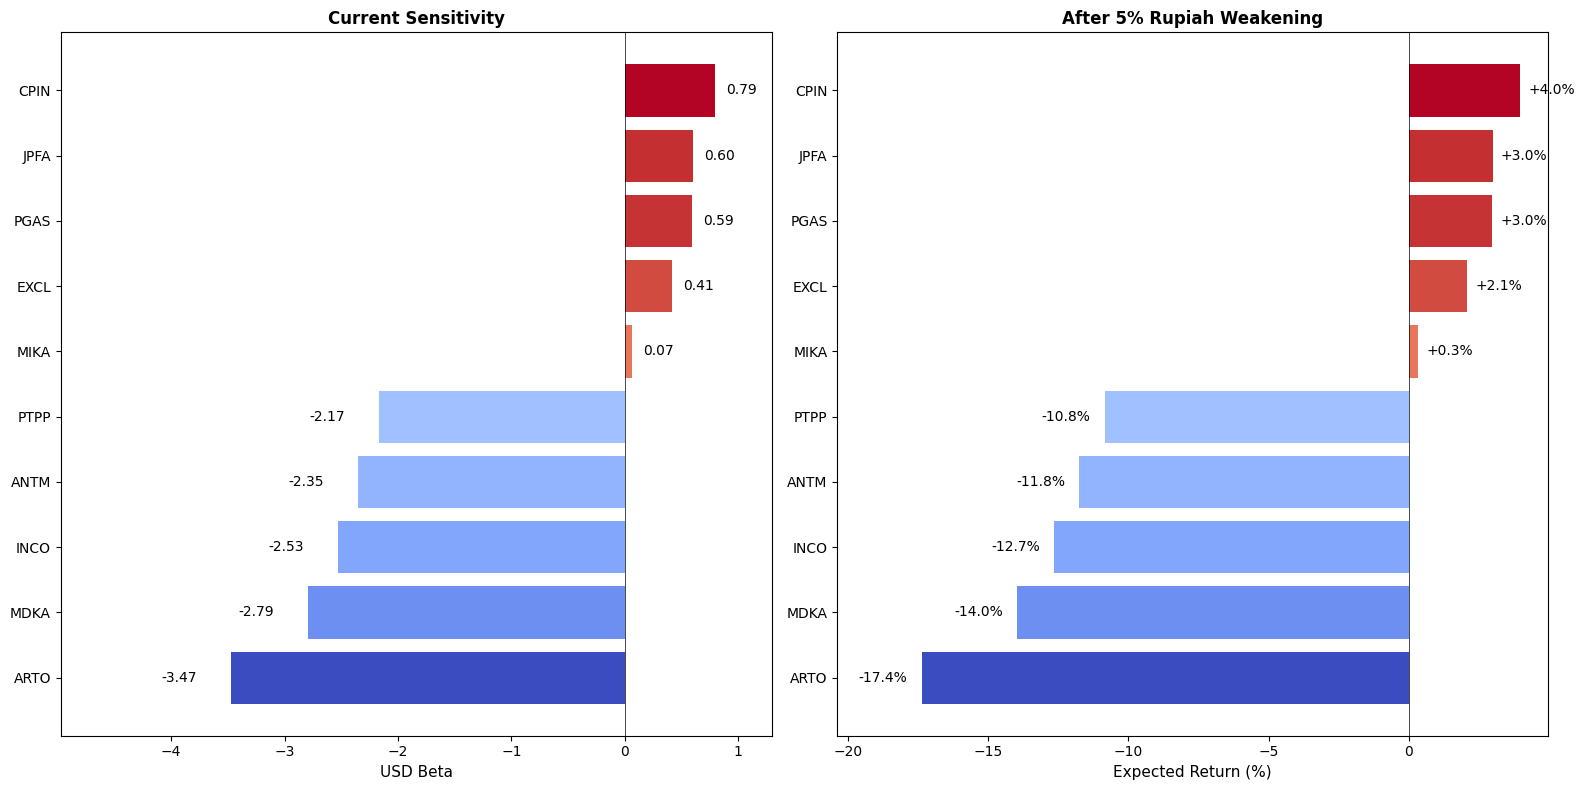

In [68]:
top5_pos = df_results[df_results['expected_return'] > 0].nlargest(5, 'expected_return')[['ticker', 'usd_beta', 'expected_return']]
top5_neg = df_results[df_results['expected_return'] < 0].nsmallest(5, 'expected_return')[['ticker', 'usd_beta', 'expected_return']]

plot_data = pd.concat([top5_pos, top5_neg]).reset_index(drop=True)
plot_data_sorted = plot_data.sort_values('expected_return', ascending=True).reset_index(drop=True)

min_usd_beta = plot_data_sorted['usd_beta'].min()
min_expected_return = plot_data_sorted['expected_return'].min()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Plot 1: USD Beta
norm1 = plt.Normalize(plot_data_sorted['usd_beta'].min(), plot_data_sorted['usd_beta'].max())
colors1 = plt.cm.coolwarm(norm1(plot_data_sorted['usd_beta']))
bars1 = ax1.barh(plot_data_sorted['ticker'], plot_data_sorted['usd_beta'], color=colors1)
ax1.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax1.set_xlim(min_usd_beta - 1.5, plot_data_sorted['usd_beta'].max() + 0.5)
ax1.set_xlabel('USD Beta', fontsize=11)
ax1.set_title('Current Sensitivity', fontsize=12, fontweight='bold')

# Add value labels for USD Beta
for bar in bars1:
    width = bar.get_width()
    y_pos = bar.get_y() + bar.get_height()/2
    x_pos = width + 0.1 if width > 0 else width - 0.3
    ha = 'left' if width > 0 else 'right'
    ax1.text(x_pos, y_pos, f'{width:.2f}',
             va='center', ha=ha, fontsize=10, color='black')

# Plot 2: Expected Return
norm2 = plt.Normalize(plot_data_sorted['expected_return'].min(), plot_data_sorted['expected_return'].max())
colors2 = plt.cm.coolwarm(norm2(plot_data_sorted['expected_return']))
bars2 = ax2.barh(plot_data_sorted['ticker'], plot_data_sorted['expected_return'], color=colors2)
ax2.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax2.set_xlim(min_expected_return - 3, plot_data_sorted['expected_return'].max() + 1)
ax2.set_xlabel('Expected Return (%)', fontsize=11)
ax2.set_title(f'After {rupiah_weakening}% Rupiah Weakening', fontsize=12, fontweight='bold')

# Add value labels for Expected Return
for bar in bars2:
    width = bar.get_width()
    y_pos = bar.get_y() + bar.get_height()/2
    if width < 0:
        ax2.text(width - 0.5, y_pos, f'{width:.1f}%',
                 va='center', ha='right', fontsize=10, color='black')
    else:
        ax2.text(width + 0.3, y_pos, f'+{width:.1f}%',
                 va='center', ha='left', fontsize=10, color='black')

plt.subplots_adjust(wspace=0.3)
plt.tight_layout()
plt.show()

In [55]:
# Cek nama kolom yang tersedia
print(df_results.columns.tolist())
print(plot_data.columns.tolist())

['ticker', 'usd_beta', 'correlation', 'p_value', 'r_squared', 'significant', 'expected_return']
['usd_beta', 'correlation', 'p_value', 'r_squared', 'significant', 'expected_return']


###3. If BI rate increases by 50bps to defend rupiah, which stocks would face the most pressure?

In [34]:
# Stocks most pressured by rate hike
# Logic: High negative USD beta indicates growth stocks
# that are most vulnerable to rising interest rates

rate_hike_sensitive = df_results[df_results['usd_beta'] < -1.5].sort_values('usd_beta', ascending=True)

print("If BI rate increases by 50bps (0.5%) to defend rupiah:")
print("Stocks that would face the most pressure:")
print(rate_hike_sensitive[['ticker', 'usd_beta']].head(10).to_string(index=False))

print("\nReasoning:")
print("- These stocks have highly negative USD beta (sensitivity to rupiah)")
print("- They are typically growth stocks or companies with high foreign debt")
print("- Rising rates increase their cost of capital and reduce valuations")

If BI rate increases by 50bps (0.5%) to defend rupiah:
Stocks that would face the most pressure:
ticker  usd_beta
  ARTO    -3.474
  MDKA    -2.793
  INCO    -2.531
  ANTM    -2.350
  PTPP    -2.168
  HRUM    -1.925
  GOTO    -1.743
  BBTN    -1.734
  BBRI    -1.675
  BBNI    -1.620

Reasoning:
- These stocks have highly negative USD beta (sensitivity to rupiah)
- They are typically growth stocks or companies with high foreign debt
- Rising rates increase their cost of capital and reduce valuations


###4. If the rupiah unexpectedly strengthens to 15.500, which stocks would benefit the most?

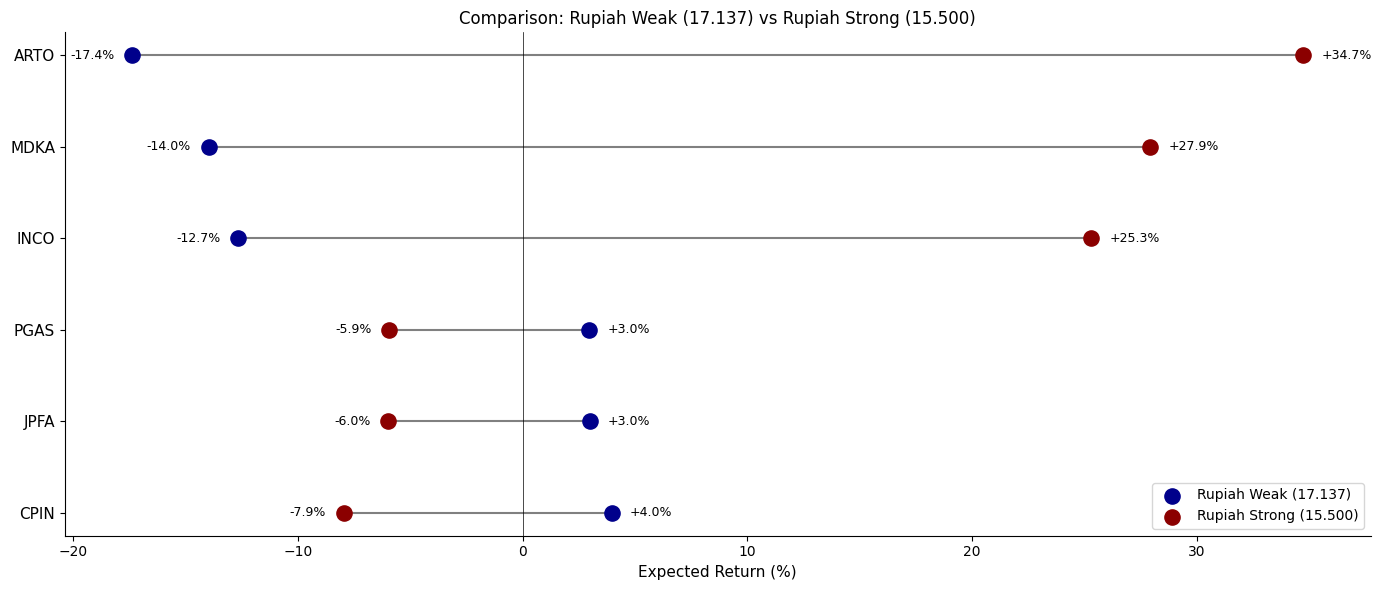

In [87]:
# Dumbbell plot untuk perbandingan dua skenario
fig, ax = plt.subplots(figsize=(14, 6))

for i, row in plot_data.iterrows():
    # Garis penghubung
    ax.plot([row['expected_return_weak'], row['expected_return_strong']], [i, i],
            color='gray', linewidth=1.5)
    # Titik untuk weak
    ax.scatter(row['expected_return_weak'], i, color='darkblue', s=120, zorder=5, label='Rupiah Weak (17.137)' if i == 0 else '')
    # Titik untuk strong
    ax.scatter(row['expected_return_strong'], i, color='darkred', s=120, zorder=5, label='Rupiah Strong (15.500)' if i == 0 else '')

# Add value labels untuk weak
for i, row in plot_data.iterrows():
    val = row['expected_return_weak']
    y_pos = i
    if val > 0:
        ax.text(val + 0.8, y_pos, f'+{val:.1f}%', va='center', ha='left', fontsize=9, color='black')
    else:
        ax.text(val - 0.8, y_pos, f'{val:.1f}%', va='center', ha='right', fontsize=9, color='black')

# Add value labels untuk strong
for i, row in plot_data.iterrows():
    val = row['expected_return_strong']
    y_pos = i
    if val > 0:
        ax.text(val + 0.8, y_pos, f'+{val:.1f}%', va='center', ha='left', fontsize=9, color='black')
    else:
        ax.text(val - 0.8, y_pos, f'{val:.1f}%', va='center', ha='right', fontsize=9, color='black')

ax.set_yticks(range(len(plot_data)))
ax.set_yticklabels(plot_data['ticker'], fontsize=11)
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax.set_xlabel('Expected Return (%)', fontsize=11)
ax.set_title('Comparison: Rupiah Weak (17.137) vs Rupiah Strong (15.500)', fontsize=12)
ax.legend(loc='lower right', fontsize=10)

# Hilangkan border atas dan kanan
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Beri ruang ekstra di kiri dan kanan
ax.set_xlim(plot_data['expected_return_weak'].min() - 3, plot_data['expected_return_strong'].max() + 3)

plt.tight_layout()
plt.show()

Key Takeaways

The current situation makes USD/IDR movement go higher than ever before in Indonesia. Contrary to common assumption, no LQ45 stock shows statistically significant positive USD beta at 95% confidence level. This suggests that even though some stocks have different sensitivity than others, it doesn't change the fact that their main financial income still comes from domestic public consumption. With life necessities getting more expensive, there's no way that CPIN and JPFA are not moving.

CPIN and JPFA are poultry producers. Chicken is the cheapest protein in Indonesia. When the economy gets hard, people switch from beef to chicken. Plus, the government nutrition program creates a demand floor for them. They have pricing power, when their costs go up because of weak rupiah (imported feed), they can pass it to consumers. That's why their USD beta is positive even though fundamentally they are importers.

PGAS has positive USD beta because their gas contracts are indexed to USD. When rupiah weakens, their revenue in IDR goes up while their operational costs stay mostly in IDR. Simple math.

On the other hand, ARTO shows highly negative USD beta at -3.47. This is a digital bank. Their whole business model depends on cheap funding and foreign investor sentiment. When BI rate stays high to defend rupiah, their cost of capital goes up and foreign investors run away. That's why they get crushed the hardest.

MDKA and INCO also show highly negative USD beta. These are mining companies. You would think they benefit from weak rupiah because they export. But here's the catch; their debt and operational costs are in USD. Their USD revenue is smaller than their USD liabilities. So when rupiah weakens, they lose more than they gain. Plus, the US currently doesn't need more nickel. Global demand is down. That makes it worse.

So the bottom line is: positive USD beta doesn't always mean "pure exporter". It means net exposure after subtracting USD debt and import costs. And negative USD beta doesn't always mean "bad company". It just means they are structurally vulnerable to currency shocks.


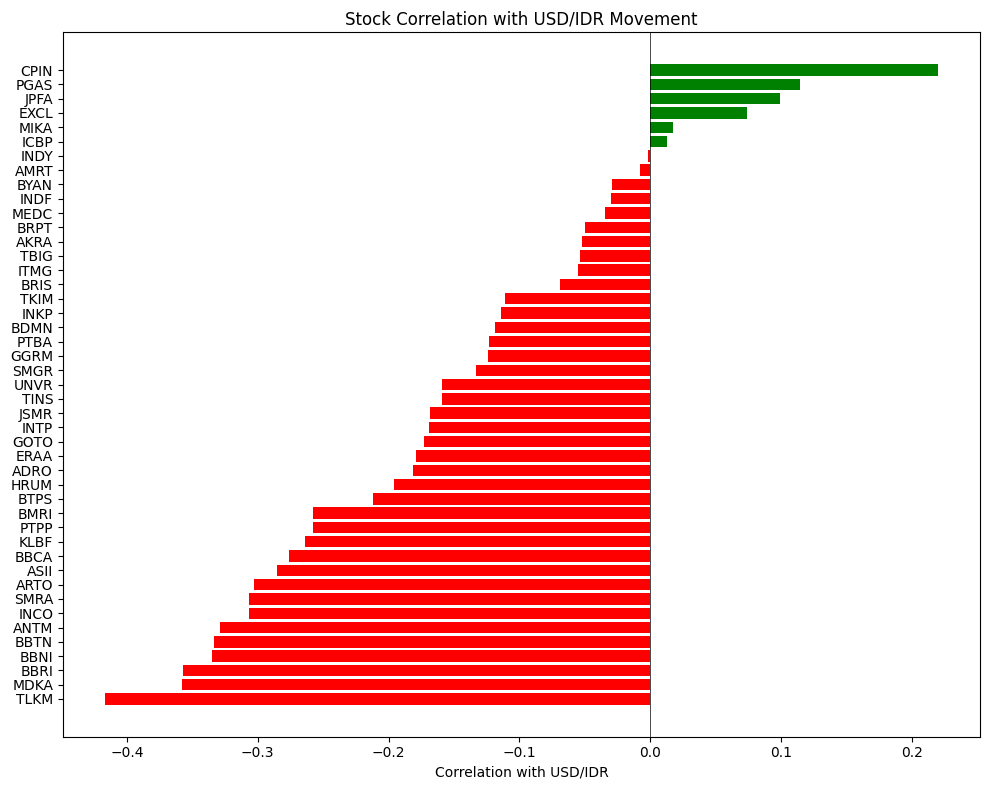

In [88]:
# Plot USD Correlation
usd_corr_plot = df_results.set_index('ticker')['correlation'].sort_values()

plt.figure(figsize=(10, 8))
colors = ['red' if x < 0 else 'green' for x in usd_corr_plot.values]
plt.barh(usd_corr_plot.index, usd_corr_plot.values, color=colors)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.xlabel('Correlation with USD/IDR')
plt.title('Stock Correlation with USD/IDR Movement')
plt.tight_layout()
plt.show()